# **Predicting Taxi Gratuities in NYC**
**Stage 2 - Exploratory data analysis**

### **Situation**
We're in the early stages of this project, having completed our initial planning phase and some early Python setup.

In this stage we need to perform EDA and data visualization work for the New York City Taxi and Limousine Commission (New York City TLC) to get a general understanding of what taxi ridership looks like. This Python notebook shows how we structured and cleaned our data, along with matplotlib/seaborn plots to help explain the insights. We have included a box plot of ride durations and key time series breakdowns by month.

Additionally, we need to include Tableau visualizations. For this taxi data, we created a Tableau dashboard showing a map of taxi/limo trips by month. We made sure it is highly accessible, keeping in mind visually impaired stakeholders.

### Exploratory Data Analysis

In this stage, we will examine our provided data and prepare it for analysis. We will also design professional data visualizations that tell a story, helping us drive decisions based on business needs.

**The purpose** of this stage is to conduct exploratory data analysis on our data set. Our mission is to continue the investigation we began in stage 1 and perform further EDA on this data with the aim of learning more about our variables.
  
**The goal** is to clean our data set and build impactful visualizations.
<br/>  
This stage is splitted into 4 parts:*

**Part 1:** Imports, links, and loading

**Part 2:** Data Exploration & Cleaning

**Part 3:** Building visualizations

**Part 4:** Evaluating and sharing results

# **Visualizing our story in Tableau and Python**

# **PACE stages**

Throughout this notebook, we structured our workflow using the PACE problem-solving framework. I have labeled our components with their respective PACE stage: Plan, Analyze, Construct, and Execute.

## PACE: Plan

* The best methods for identifing outliers are using box plot and the interquantile approach.
* Depending on the outlier's type, if it's general then it must be execluded, else we might keep it or replace it with another value.

### Part 1. Imports, links, and loading
We utilize Tableau Public for [supplemental interactive dashboards](https://public.tableau.com/views/NewYorkNLCViz/Sheet1?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link).


For our Python-based EDA, we import our essential packages and libraries, specifically pandas, numpy, and matplotlib/seaborn.

In [ ]:
# Importing our required packages and libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [ ]:
# Loading our dataset into a pandas dataframe
df = pd.read_csv('2017_Yellow_Taxi_Trip_Data.csv')

## PACE: Analyze

Let's reflect on our Analyze stage to determine our data assessment strategy.

### Part 2a. Data exploration and cleaning

Deciding which columns are applicable

Our first step is to assess the data. We checked our data profile to get a sense of the scale, structure, and makeup of our dataset.

Let's use core pandas functions to structure and understand our dataset:
*    head()
*    describe()
*    info()
*    groupby()
*    sort_values()

+ data columns that are most applicable are `Tpep Pickup Datetime`, `tpep_dropoff_datetime` , `passenger_count` ,`trip_distance`, `fare_amount` , `total_amount`. The others can be dropped for the purpose of this project,
+ There are no missing data, if there was, they can be dropped or replaced with mean or median value, or set to new catrgory named `NaN`.
+ There are many outliers in `trip_distance`,`tip amount` and `total_amount`.
+ The distribution of data can inform me of the mean, median and if there were outliers.

We will start our exploration by calling head and checking the size.

In [ ]:
# Inspecting the first few rows of our dataframe
df.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80


In [ ]:
# Checking the total size of our dataset
df.size

408582

Let's generate descriptive statistics...

In [ ]:
# Obtaining descriptive statistics for our numeric columns
df.describe()

,Unnamed: 0,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,2.269900e+04,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000
mean,5.675849e+07,1.556236,1.642319,2.913313,1.043394,162.412353,161.527997,1.336887,13.026629,0.333275,0.497445,1.835781,0.312542,0.299551,16.310502
std,3.274493e+07,0.496838,1.285231,3.653171,0.708391,66.633373,70.139691,0.496211,13.243791,0.463097,0.039465,2.800626,1.399212,0.015673,16.097295
min,1.212700e+04,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-120.000000,-1.000000,-0.500000,0.000000,0.000000,-0.300000,-120.300000
25%,2.852056e+07,1.000000,1.000000,0.990000,1.000000,114.000000,112.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.750000
50%,5.673150e+07,2.000000,1.000000,1.610000,1.000000,162.000000,162.000000,1.000000,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.800000
75%,8.537452e+07,2.000000,2.000000,3.060000,1.000000,233.000000,233.000000,2.000000,14.500000,0.500000,0.500000,2.450000,0.000000,0.300000,17.800000
max,1.134863e+08,2.000000,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,999.990000,4.500000,0.500000,200.000000,19.100000,0.300000,1200.290000


Let's inspect our data types and non-null counts.

In [ ]:
# Printing our dataframe information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  float64
 15  to

### Part 2b. Assessing dimensions and measures

In Tableau, we double-checked that our data types, dimensions, and measures were correctly mapped.

Now in Python, we examine our column types. Do they make sense for our analysis?

We reviewed our design guidelines to establish the base structure of our Tableau dashboard.

### Part 2c. Selecting our visualization types

We want to pick visualization types that help us uncover hidden patterns and easily explain the data to our team.

Now that we've identified our key variables, we select the visual elements that make the most sense for our exploratory analysis:
* Bar charts
* Box plots
* Histograms
* Heat maps
* Scatter plots

## PACE: Construct

We transition into building our visualizations during our Construct stage.

### Part 3. Building our data visualizations

We've completed our assessment and selected our key features. Let's start plotting our visualizations!

### Analyzing Outliers with Boxplots

We'll run outlier checks on our primary fields like trip distance and trip duration using box plots and histograms.

We need to parse our date columns into datetime format so we can calculate total trip duration.

In [ ]:
# Converting our date columns to datetime objects
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

Let's explore our **trip distance**

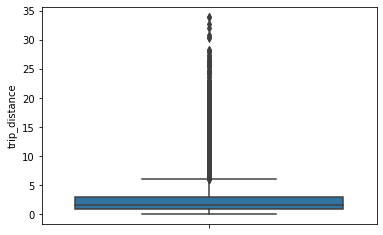

In [ ]:
# Plotting a box plot to inspect trip_distance outliers
sns.boxplot(y= df['trip_distance'])

Text(0.5, 1.0, 'Trip Distance')

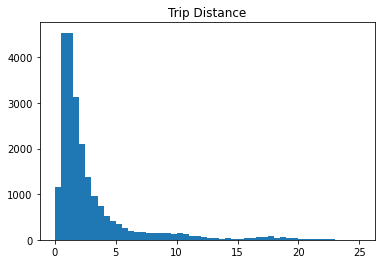

In [ ]:
# Creating a histogram to look at the distribution of trip_distance
plt.hist(df['trip_distance'],range=(0,25),bins=50);
plt.title('Trip Distance')

Let's explore our **total amount**

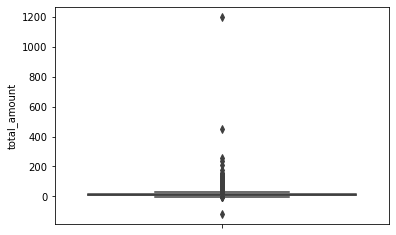

In [ ]:
# Plotting a box plot for total_amount outliers
sns.boxplot(y= df['total_amount'])

Text(0.5, 1.0, 'Total Amount')

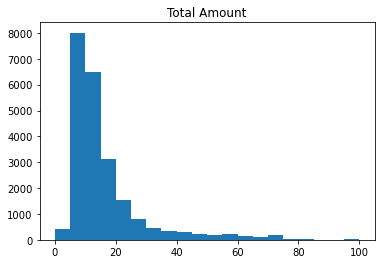

In [ ]:
# Plotting a histogram for total_amount distribution
plt.hist(df['total_amount'],range=(0,100),bins=20);
plt.title('Total Amount')

Let's explore our **tip amount**

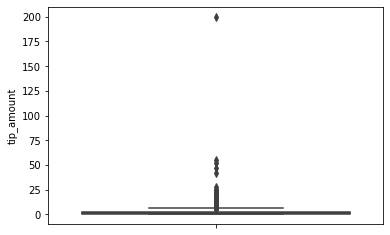

In [ ]:
# Plotting a box plot for tip_amount outliers
sns.boxplot(y= df['tip_amount'])

Text(0.5, 1.0, 'Tip Amount')

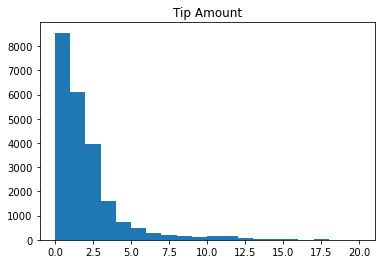

In [ ]:
# Creating a histogram for tip_amount distribution
plt.hist(x= df['tip_amount'],range=(0,20),bins=20);
plt.title('Tip Amount')

Let's examine **tip_amount by vendor**

Text(0.5, 1.0, 'Tip Amount by Vendor')

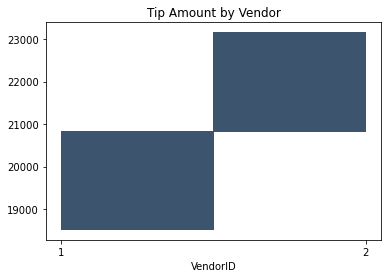

In [ ]:
# Let's plot our tip_amount grouped by vendor
y1 = df.groupby('VendorID')['tip_amount'].sum().values
x1 = y = df.groupby('VendorID')['tip_amount'].sum().index
g= sns.histplot(x=x1,y=y1,bins=2)
g.set_xticks([1,2])
plt.title("Tip Amount by Vendor");

Next, we'll zoom in on the upper range of our tips to check if Vendor 1 receives a higher share of generous tips.

(0.0, 25.0)

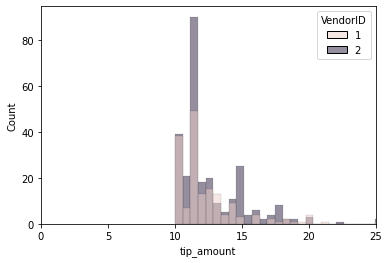

In [ ]:
# Plotting a histogram of tip_amount by vendor, filtering for tips > $10
sns.histplot(data=df[df['tip_amount']>10], x= 'tip_amount',hue='VendorID')
plt.xlim(0,25)

Let's examine **Mean tips by passenger count**

First, we'll check the unique values present in our `passenger_count` column.

In [ ]:
# Finding the unique passenger counts in our dataset
df['passenger_count'].unique()

array([6, 1, 2, 4, 5, 3, 0])

In [ ]:
# Calculating the mean tips grouped by passenger_count
df.groupby('passenger_count')['tip_amount'].mean()

passenger_count
0    2.135758
1    1.848920
2    1.856378
3    1.716768
4    1.530264
5    1.873185
6    1.720260
Name: tip_amount, dtype: float64

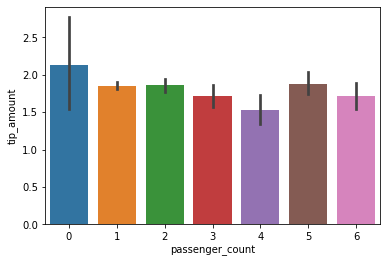

In [ ]:
# Generating a bar plot for our mean tips by passenger count
sns.barplot(data=df,x='passenger_count',y ='tip_amount',estimator=np.mean)

Let's **create month and day columns**

In [ ]:
# Extracting and creating our month column
df['month'] = df['tpep_pickup_datetime'].dt.month_name().str.slice(stop=3)
# Extracting and creating our day column
df['day'] = df['tpep_pickup_datetime'].dt.day_name()
df.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,month,day
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56,Mar,Saturday
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80,Apr,Tuesday
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75,Dec,Friday
3,38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69,May,Sunday
4,30841670,2,2017-04-15 23:32:20,2017-04-15 23:49:03,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80,Apr,Saturday


Let's **plot our total ride count by month**

We start by calculating the total ride counts for each month.

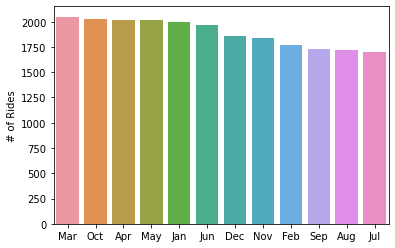

In [ ]:
# Let's find and plot our total number of rides for each month
g = sns.barplot(x=df['month'].value_counts().index ,y= df['month'].value_counts().values)
g.set_ylabel('# of Rides');

Let's reorder these results so our months follow chronological order.

In [ ]:
# Reordering our monthly lists to match calendar order
import calendar
months_short = list(calendar.month_abbr)[1:]

In [ ]:
# Verifying our ordered month list
months_short

['Jan',
 'Feb',
 'Mar',
 'Apr',
 'May',
 'Jun',
 'Jul',
 'Aug',
 'Sep',
 'Oct',
 'Nov',
 'Dec']

Text(0, 0.5, '# of Rides')

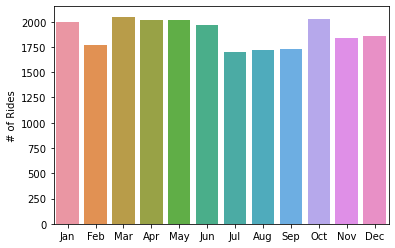

In [ ]:
# Plotting our total rides per month in chronological order
g=sns.barplot(x=df['month'].value_counts().index ,y= df['month'].value_counts().values, order=months_short)
g.set_ylabel('# of Rides')

Let's **plot our total ride count by day**

We will repeat this process to calculate and display our total rides grouped by day of the week.

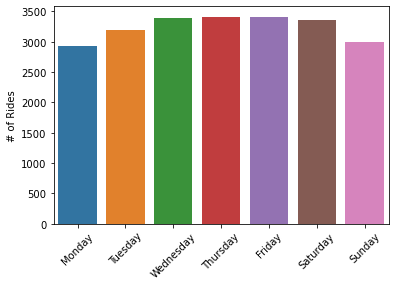

In [ ]:
# Repeating our aggregation, this time plotting rides by day of the week
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
g = sns.barplot(x=df['day'].value_counts().index ,y= df['day'].value_counts().values, order=days_order)
g.set_ylabel('# of Rides')
plt.xticks(rotation=45);

In [ ]:
# Plotting our ride count distribution by day
# We've consolidated this with our ordering cell above.

Let's **plot our total revenue by day of the week**

Now, we'll calculate and visualize our accumulated revenue for each day of the week.

In [ ]:
# Summing up our total revenue grouped by day
df.head()
df.groupby('day')['total_amount'].sum()

day
Friday       55818.74
Monday       49574.37
Saturday     51195.40
Sunday       48624.06
Thursday     57181.91
Tuesday      52527.14
Wednesday    55310.47
Name: total_amount, dtype: float64

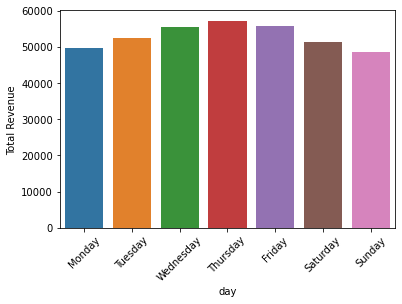

In [ ]:
# Creating our bar plot to show total revenue by day of the week
g= sns.barplot(x=df.groupby('day')['total_amount'].sum().index ,y= df.groupby('day')['total_amount'].sum().values, order=days_order)
g.set_ylabel('Total Revenue')
plt.xticks(rotation=45);

Let's **plot our total revenue by month**

In [ ]:
# Summing up our total revenue grouped by month
df.groupby('month')['total_amount'].sum()

month
Apr    32012.54
Aug    27759.56
Dec    31261.57
Feb    28937.89
Jan    31735.25
Jul    26617.64
Jun    32920.52
Mar    33085.89
May    33828.58
Nov    30800.44
Oct    33065.83
Sep    28206.38
Name: total_amount, dtype: float64

Text(0, 0.5, 'Total Revenue')

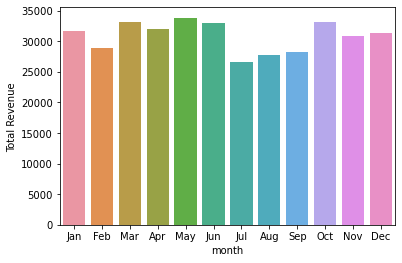

In [ ]:
# Plotting our total revenue trends across months
g= sns.barplot(x=df.groupby('month')['total_amount'].sum().index ,y= df.groupby('month')['total_amount'].sum().values, order=months_short)
g.set_ylabel('Total Revenue')

#### Scatter plot

We created a scatterplot in [Tableau Public](https://public.tableau.com/views/NewYorkNLCViz/Sheet1?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link), which can be easier to manipulate and present.

Let's **plot our mean trip distance by drop-off location**

In [ ]:
# Checking unique drop-off locations within our dataset
df.head()
locations = df['DOLocationID'].unique()

In [ ]:
# Calculating mean trip distance for each drop-off location and sorting them
myplot = df.groupby('DOLocationID')['trip_distance'].mean().sort_values(ascending=False)
myplot2 = myplot.sort_values()
myplot2

216

Text(0, 0.5, 'Avg. Trip Distance')

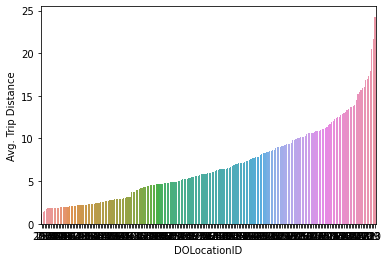

In [ ]:
# Plotting our mean trip distances by drop-off location in ascending order
g = sns.barplot(x=myplot2.index,y=myplot2.values,order=myplot2.index)
g.set_ylabel('Avg. Trip Distance')

## PACE: Execute

Let's evaluate our work during the Execute stage.

### Part 4a. Results and evaluation

Let's look at this from our client's perspective: what would they want to see?


I've set titles for important plots, the colors are already set by the library.


My client would likely want to know the relations between different parameters. and most important days and months.

### Part 4b. Conclusion



EDA is important because it gives as an overview of the data, discovering its patterns and trends and validating it. Which makes sure our data is reliable for further analysis and modeling processes to gain more insight.

Visualizations helped me understand that box plot is very useful for discovering center and disperition of the data. Bar plot is useful for discovirng patterns and trends and same for scatter plot. And histogram gives us some useful statistics of our data.